# Matplotlib Visualization using Gradio

In [1]:
import pandas as pd

# Sample Data
data = {"Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
        "Sales": [10000, 12000, 13000, 15000, 17000, 16000],
        "Profit": [2000, 3000, 4000, 2500, 3500, 3000]
       }
df = pd.DataFrame(data)

In [2]:
df

,Month,Sales,Profit
0,Jan,10000,2000
1,Feb,12000,3000
2,Mar,13000,4000
3,Apr,15000,2500
4,May,17000,3500
5,Jun,16000,3000


### Line Plot

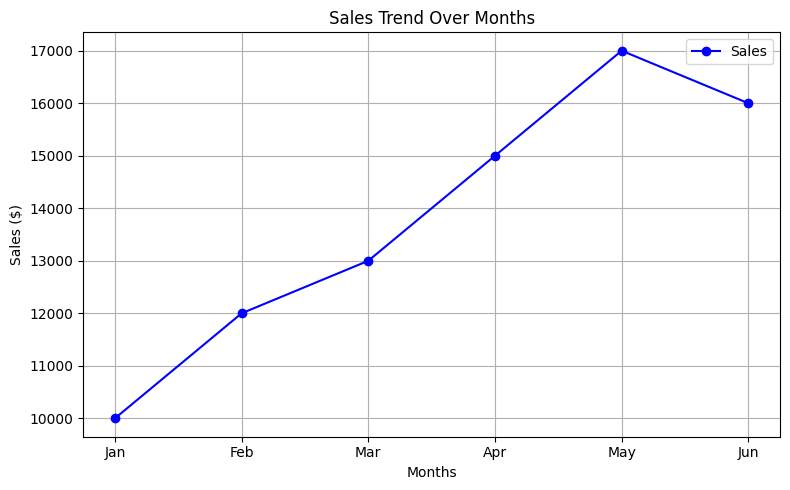

In [3]:
# 1 - Line Plot Sales Over Time
import matplotlib.pyplot as plt

#Line Plot: Sales Over Time 
plt.figure(figsize = (8, 5))
plt.plot(df['Month'], df['Sales'], color = 'blue', marker = 'o', linestyle = '-', label = 'Sales')
plt.title('Sales Trend Over Months')
plt.xlabel('Months')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Output: A line plot showing the sales trend over the months

### Bar Plot

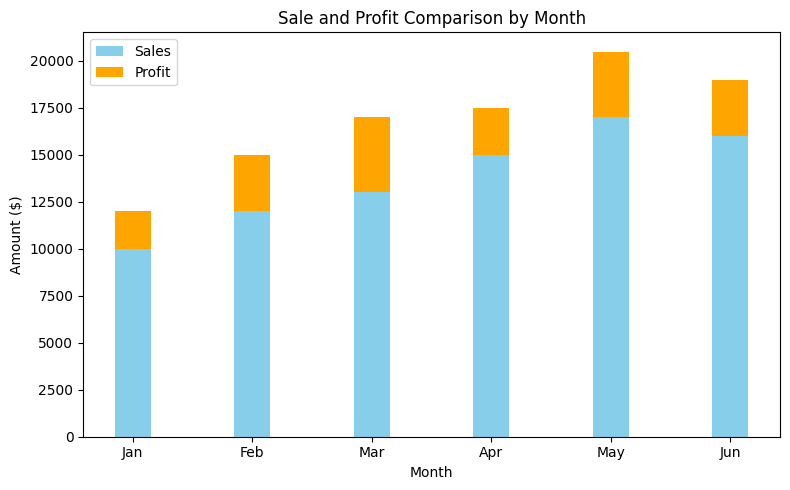

In [4]:
# Bar Plot: Sales v/s Profit by Month
plt.figure(figsize = (8, 5))
width = 0.3
plt.bar(df['Month'], df['Sales'], width = width, label = 'Sales', color = 'skyblue')
plt.bar(df['Month'], df['Profit'], width = width, label = 'Profit', color = 'orange', bottom = df['Sales'])
plt.title('Sale and Profit Comparison by Month')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()

# A stacked bar plot where you can compare Sales and Profit for each month

## Pie Chart

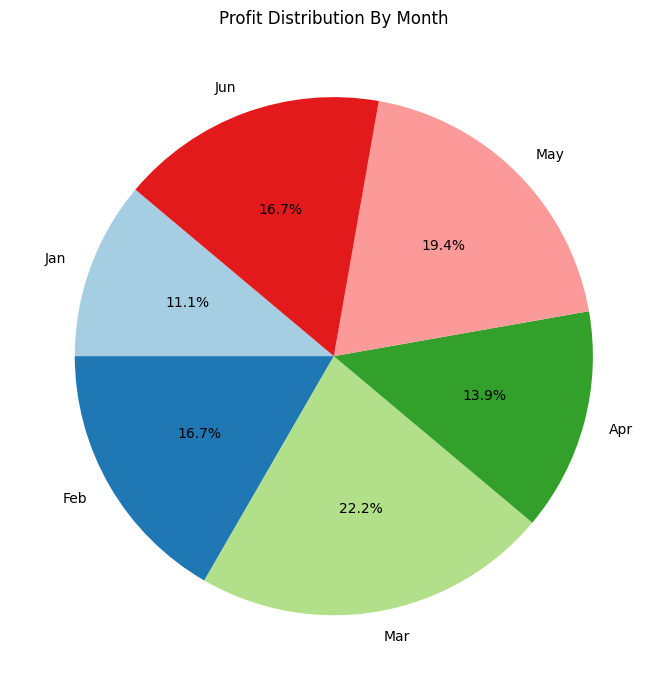

In [5]:
# Pie Chart: Profit Distribution by Month

plt.figure(figsize = (7, 7))
plt.pie(df['Profit'], labels = df['Month'], autopct = '%1.1f%%', startangle = 140, colors = plt.cm.Paired.colors)
plt.title('Profit Distribution By Month')
plt.tight_layout()
plt.show()

# A pie chart displaying the proportion of profit distribution for each month

## Scatter Plot

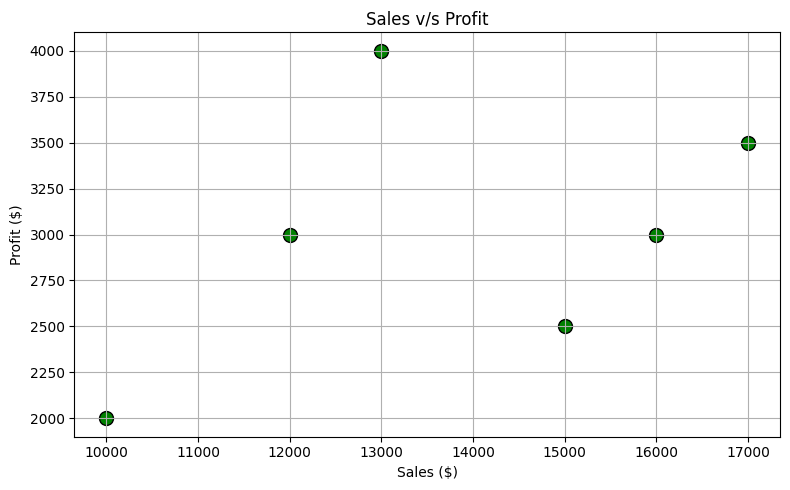

In [6]:
# Scatter Plot: Sales v/s Profit (Correlation)

plt.figure(figsize = (8, 5))
plt.scatter(df['Sales'], df['Profit'], color = 'green', s = 100, edgecolors = 'black')
plt.title('Sales v/s Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

# A scatter plot showing the correlation between sales and profit.

## Histogram

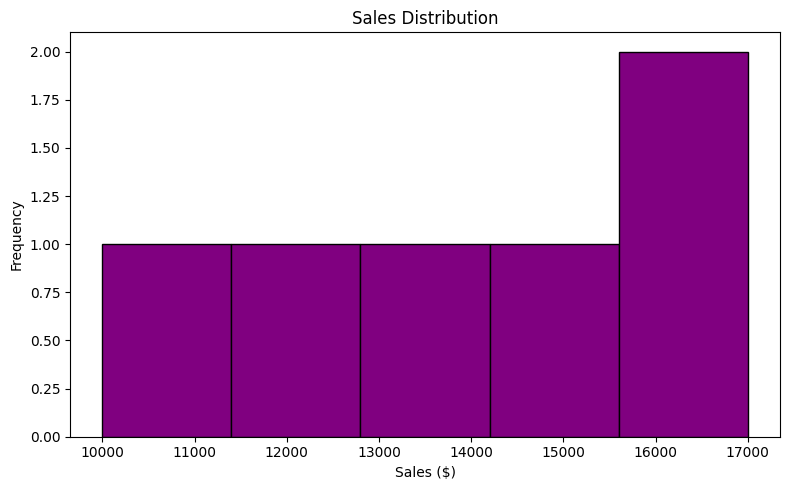

In [7]:
# Histogram: Distribution of Sales
plt.figure(figsize = (8, 5))
plt.hist(df['Sales'], bins = 5, color = 'purple', edgecolor = 'black')
plt.title('Sales Distribution')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# A histogram showing the distribution of sales values for months.

## Box Plot

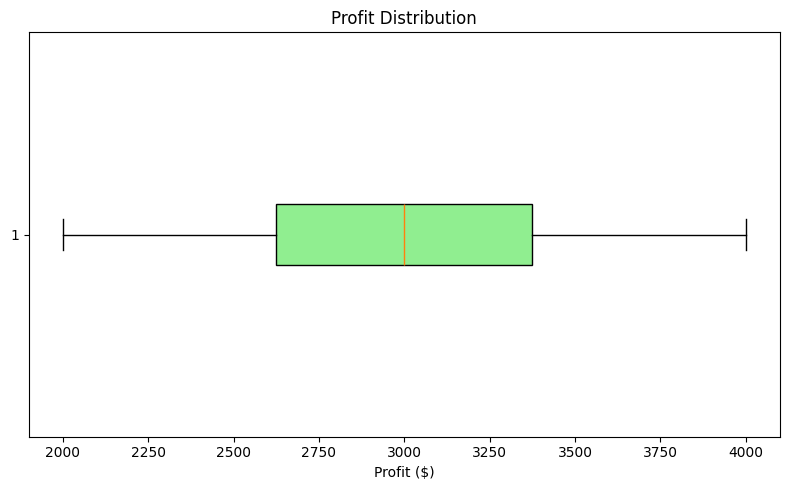

In [8]:
# Box Plot: Profit Distribution
plt.figure(figsize = (8, 5))
plt.boxplot(df['Profit'], vert = False, patch_artist = True, boxprops = dict(facecolor = "lightgreen"))
plt.title('Profit Distribution')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.show()

# A box plot showing the spread and outliers of Profit

In [9]:
# Import necessary libraries
import gradio as gr          # For creating interactive web apps
import pandas as pd          # For handling and analyzing data
import matplotlib.pyplot as plt  # For data visualization

# -----------------------------
# Sample Data
# -----------------------------
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],   # Months
    "Sales": [10000, 12000, 13000, 15000, 17000, 16000],  # Sales figures
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]        # Profit figures
}
df = pd.DataFrame(data)  # Convert dictionary to DataFrame for easy plotting

# -----------------------------
# Function to generate plots
# -----------------------------
def generate_plot(plot_type):
    # Create a figure with a fixed size
    fig = plt.figure(figsize=(8, 5))

    # Line Plot
    if plot_type == "Line Plot":
        plt.plot(df['Month'], df['Sales'], color='blue', marker='o', linestyle='-', label='Sales')
        plt.title('Sales Trend Over Months')
        plt.xlabel('Months')
        plt.ylabel('Sales ($)')
        plt.grid(True)
        plt.legend()

    # tacked Bar Chart
    elif plot_type == "Stacked Bar Chart":
        fig.set_size_inches(8, 5)  # Adjust figure size
        width = 0.3                # Bar width
        plt.bar(df['Month'], df['Sales'], width=width, label='Sales', color='skyblue')
        plt.bar(df['Month'], df['Profit'], width=width, label='Profit', color='orange', bottom=df['Sales'])
        plt.title('Sales and Profit Comparison by Month')
        plt.xlabel('Month')
        plt.ylabel('Amount ($)')
        plt.legend()
        
    # Pie Chart
    elif plot_type == "Pie Chart":
        fig.set_size_inches(7, 7)  # Use same figure instead of creating a new one
        plt.pie(df['Profit'], labels=df['Month'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
        plt.title('Profit Distribution By Month')

    # Scatter Plot
    elif plot_type == "Scatter Plot":
        plt.scatter(df['Sales'], df['Profit'], color='green', s=100, edgecolors='black')
        plt.title('Sales vs Profit')
        plt.xlabel('Sales ($)')
        plt.ylabel('Profit ($)')
        plt.grid(True)

    # Histogram
    elif plot_type == "Histogram":
        plt.hist(df['Sales'], bins=5, color='purple', edgecolor='black')
        plt.title('Sales Distribution')
        plt.xlabel('Sales ($)')
        plt.ylabel('Frequency')

    # Box Plot
    elif plot_type == "Box Plot":
        plt.boxplot(df['Profit'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
        plt.title('Profit Distribution')
        plt.xlabel('Profit ($)')

    # Adjust layout to prevent overlaps
    plt.tight_layout()
    return fig  # Return the Matplotlib figure to Gradio

# -----------------------------
# Gradio User Interface
# -----------------------------
demo = gr.Interface(
    fn=generate_plot,  # Function to call when user selects a plot
    inputs=gr.Radio(   # Radio button input for selecting plot type
        ["Line Plot", "Stacked Bar Chart", "Pie Chart", "Scatter Plot", "Histogram", "Box Plot"],
        label="Choose Plot Type"
    ),
    outputs=gr.Plot(label="Visualization"),  # Display the Matplotlib figure
    title="Sales & Profit Visual Explorer",  # App title
    description="Choose a chart type to visualize the data."  # Short description
)

# Launch the app
demo.launch()

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
